# Vision Situation Analysis Review

Review notebook for the updated Vision/DL direction after the meeting.

This notebook checks event-window candidates, key-frame roles, object changes, evidence images, and grounded summary text. It does not validate fault ratio, legal liability, or final accident type.


## 1. Check project paths and generated outputs

Find the project root and count existing detection, agent-output, and visualization files.


In [1]:
from pathlib import Path
import json
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "scripts":
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUT_DIR = PROJECT_ROOT / "storage/vision/outputs"
DETECTION_DIR = OUTPUT_DIR / "detections"
AGENT_OUTPUT_DIR = OUTPUT_DIR / "agent_outputs"
VIS_DIR = OUTPUT_DIR / "visualizations"

print("project_root:", PROJECT_ROOT)
print("detections:", len(list(DETECTION_DIR.glob("detections_*.json"))))
print("agent_outputs:", len(list(AGENT_OUTPUT_DIR.glob("agent_output_*.json"))))
print("visualizations:", len(list(VIS_DIR.glob("*_bbox.jpg"))))


project_root: /workspace/SKN27-FINAL-3Team
detections: 1
agent_outputs: 1
visualizations: 5


## 1-A. Run full Vision pipeline

Run this cell when you want the notebook to regenerate all outputs from the current raw video. It executes the same `.py` files that were previously run in the RunPod terminal.


In [ ]:
# AUTO_RUN_FULL_VISION_PIPELINE
import subprocess
import sys

RUN_FULL_PIPELINE = True

commands = [
    [sys.executable, "scripts/check_raw_media.py"],
    [sys.executable, "ai/vision/pipeline.py"],
    [sys.executable, "ai/vision/models.py"],
    [sys.executable, "ai/vision/schemas.py"],
    [sys.executable, "ai/vision/visualize.py"],
    [sys.executable, "etl/build_clip_candidates.py", "--short-video-sec", "10"],
    [sys.executable, "etl/extract_video_clips.py", "--overwrite"],
    [sys.executable, "etl/extract_videomae_frames.py", "--overwrite"],
    [sys.executable, "ai/vision/videomae_infer.py"],
    [sys.executable, "ai/vision/merge_analysis.py"],
]

if RUN_FULL_PIPELINE:
    for command in commands:
        print("\n$", " ".join(command))
        completed = subprocess.run(command, cwd=PROJECT_ROOT, text=True, capture_output=True)
        if completed.stdout:
            print(completed.stdout)
        if completed.stderr:
            print(completed.stderr)
        completed.check_returncode()
else:
    print("RUN_FULL_PIPELINE is False. Set it to True to regenerate outputs.")


## 2. Load latest Vision Agent Output

Load the latest JSON generated by `ai/vision/schemas.py`. This is the structure passed to RAG/report/UI layers.


In [2]:
def latest(pattern_dir, pattern):
    files = sorted(pattern_dir.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No files found: {pattern_dir / pattern}")
    return files[-1]

agent_output_path = latest(AGENT_OUTPUT_DIR, "agent_output_*.json")
agent_data = json.loads(agent_output_path.read_text(encoding="utf-8"))
agent = agent_data["agent_output"]
result = agent["structured_result"]

print("agent_output_path:", agent_output_path)
print("schema_version:", agent["metadata"]["schema_version"])
print("node_code:", agent["node_code"])
print("status:", agent["status"])
print("summary:", agent["summary"])


agent_output_path: /workspace/SKN27-FINAL-3Team/storage/vision/outputs/agent_outputs/agent_output_bb_3_190909_pedestrian_226_21450.json
schema_version: vision-agent-output-v2
node_code: accident_situation_analysis
status: success
summary: video key frame에서 car 15건, person 1건이 탐지되었습니다. 2.933~9.467초 구간이 우선 확인 후보입니다. 이 결과는 관찰 근거이며 과실비율, 가해 차량, 법적 책임을 확정하지 않습니다.


## 3. Review event-window candidates

These candidates are produced from bbox motion, object appearance/disappearance, and key-frame timestamp context.


In [3]:
event_windows = result.get("event_window_candidates", [])
for item in event_windows:
    print(json.dumps(item, ensure_ascii=False, indent=2))


{
  "event_candidate_id": "event_window_01",
  "event_window_start_sec": 2.933,
  "event_window_end_sec": 9.467,
  "priority_score": 1.0,
  "source_refs": [
    "frame_03",
    "frame_04"
  ],
  "basis": "bbox_motion_peak_with_2sec_context",
  "clip_status": "candidate_for_inference"
}


## 4. Review key-frame roles

Check whether each frame is treated as event_before, risk_increase, event_peak, event_after, or fallback.


In [4]:
for frame in result.get("key_frames", []):
    print(
        frame.get("frame_id"),
        "role=" + str(frame.get("frame_role")),
        "time=" + str(frame.get("timestamp_sec")),
        "reason=" + str(frame.get("selection_reason")),
        "path=" + str(frame.get("frame_path")),
    )


frame_01 role=event_before time=0.0 reason=before_bbox_motion_peak path=storage/vision/processed/frames/bb_3_190909_pedestrian_226_21450_frame_01_000000.jpg
frame_02 role=event_before time=2.467 reason=before_bbox_motion_peak path=storage/vision/processed/frames/bb_3_190909_pedestrian_226_21450_frame_02_000037.jpg
frame_03 role=risk_increase time=4.933 reason=before_bbox_motion_peak path=storage/vision/processed/frames/bb_3_190909_pedestrian_226_21450_frame_03_000074.jpg
frame_04 role=event_peak time=7.467 reason=bbox_motion_peak_candidate path=storage/vision/processed/frames/bb_3_190909_pedestrian_226_21450_frame_04_000112.jpg
frame_05 role=event_after time=9.933 reason=after_bbox_motion_peak path=storage/vision/processed/frames/bb_3_190909_pedestrian_226_21450_frame_05_000149.jpg


## 5. Review object-change evidence

Check motion score, bbox center movement, area change, appeared classes, and disappeared classes between sampled frames.


In [5]:
changes = result.get("object_change_observations", [])
print("change_count:", len(changes))
for item in changes[:10]:
    print(json.dumps(item, ensure_ascii=False, indent=2))


change_count: 4
{
  "source_refs": [
    "frame_01",
    "frame_02"
  ],
  "from_timestamp_sec": 0.0,
  "to_timestamp_sec": 2.467,
  "motion_score": 4.0587,
  "object_motion": [
    {
      "class_name": "car",
      "center_move_px": 405.87,
      "bbox_area_change": 154887.58
    }
  ],
  "appeared_classes": [],
  "disappeared_classes": [],
  "basis": "class_level_bbox_change_between_sampled_keyframes"
}
{
  "source_refs": [
    "frame_02",
    "frame_03"
  ],
  "from_timestamp_sec": 2.467,
  "to_timestamp_sec": 4.933,
  "motion_score": 4.0606,
  "object_motion": [
    {
      "class_name": "car",
      "center_move_px": 406.06,
      "bbox_area_change": 153137.68
    }
  ],
  "appeared_classes": [],
  "disappeared_classes": [],
  "basis": "class_level_bbox_change_between_sampled_keyframes"
}
{
  "source_refs": [
    "frame_03",
    "frame_04"
  ],
  "from_timestamp_sec": 4.933,
  "to_timestamp_sec": 7.467,
  "motion_score": 4.5435,
  "object_motion": [
    {
      "class_name": "car

## 6. Review detected objects

Check object-level class, confidence, and bbox. There is no single generic confidence for the whole analysis.


In [6]:
objects = result.get("detected_objects", [])
print("detected_objects:", len(objects))
for obj in objects[:20]:
    print(obj["source_ref"], obj["class_name"], obj["confidence"], obj["bbox"]["values"])


detected_objects: 16
frame_01 car 0.8653 [952.23, 387.69, 1489.88, 859.93]
frame_01 car 0.8639 [1436.85, 341.24, 1769.12, 643.05]
frame_02 car 0.8652 [1439.52, 341.29, 1769.77, 641.1]
frame_02 car 0.7932 [958.37, 393.18, 1489.43, 824.78]
frame_02 car 0.3024 [1343.91, 274.16, 1685.56, 499.07]
frame_03 car 0.8841 [955.68, 391.93, 1489.15, 864.59]
frame_03 car 0.8745 [1438.95, 341.72, 1769.93, 638.23]
frame_03 car 0.6557 [863.57, 391.86, 1018.57, 480.86]
frame_03 car 0.2868 [1342.95, 272.67, 1688.0, 496.28]
frame_04 person 0.8564 [548.48, 356.32, 755.36, 776.84]
frame_04 car 0.8545 [1436.83, 342.82, 1769.15, 640.51]
frame_04 car 0.8512 [941.36, 387.95, 1491.94, 818.99]
frame_04 car 0.5011 [891.61, 392.96, 1030.12, 476.63]
frame_04 car 0.2719 [1337.42, 270.15, 1687.46, 480.73]
frame_05 car 0.8547 [1437.03, 342.11, 1768.76, 641.57]
frame_05 car 0.8484 [949.46, 388.46, 1490.91, 861.05]


## 7. Display bbox visualization images

These images are useful for review and presentation. Run `ai/vision/visualize.py` first if none are shown.


visualization_images: 5
/workspace/SKN27-FINAL-3Team/storage/vision/outputs/visualizations/bb_3_190909_pedestrian_226_21450_frame_01_000000_bbox.jpg


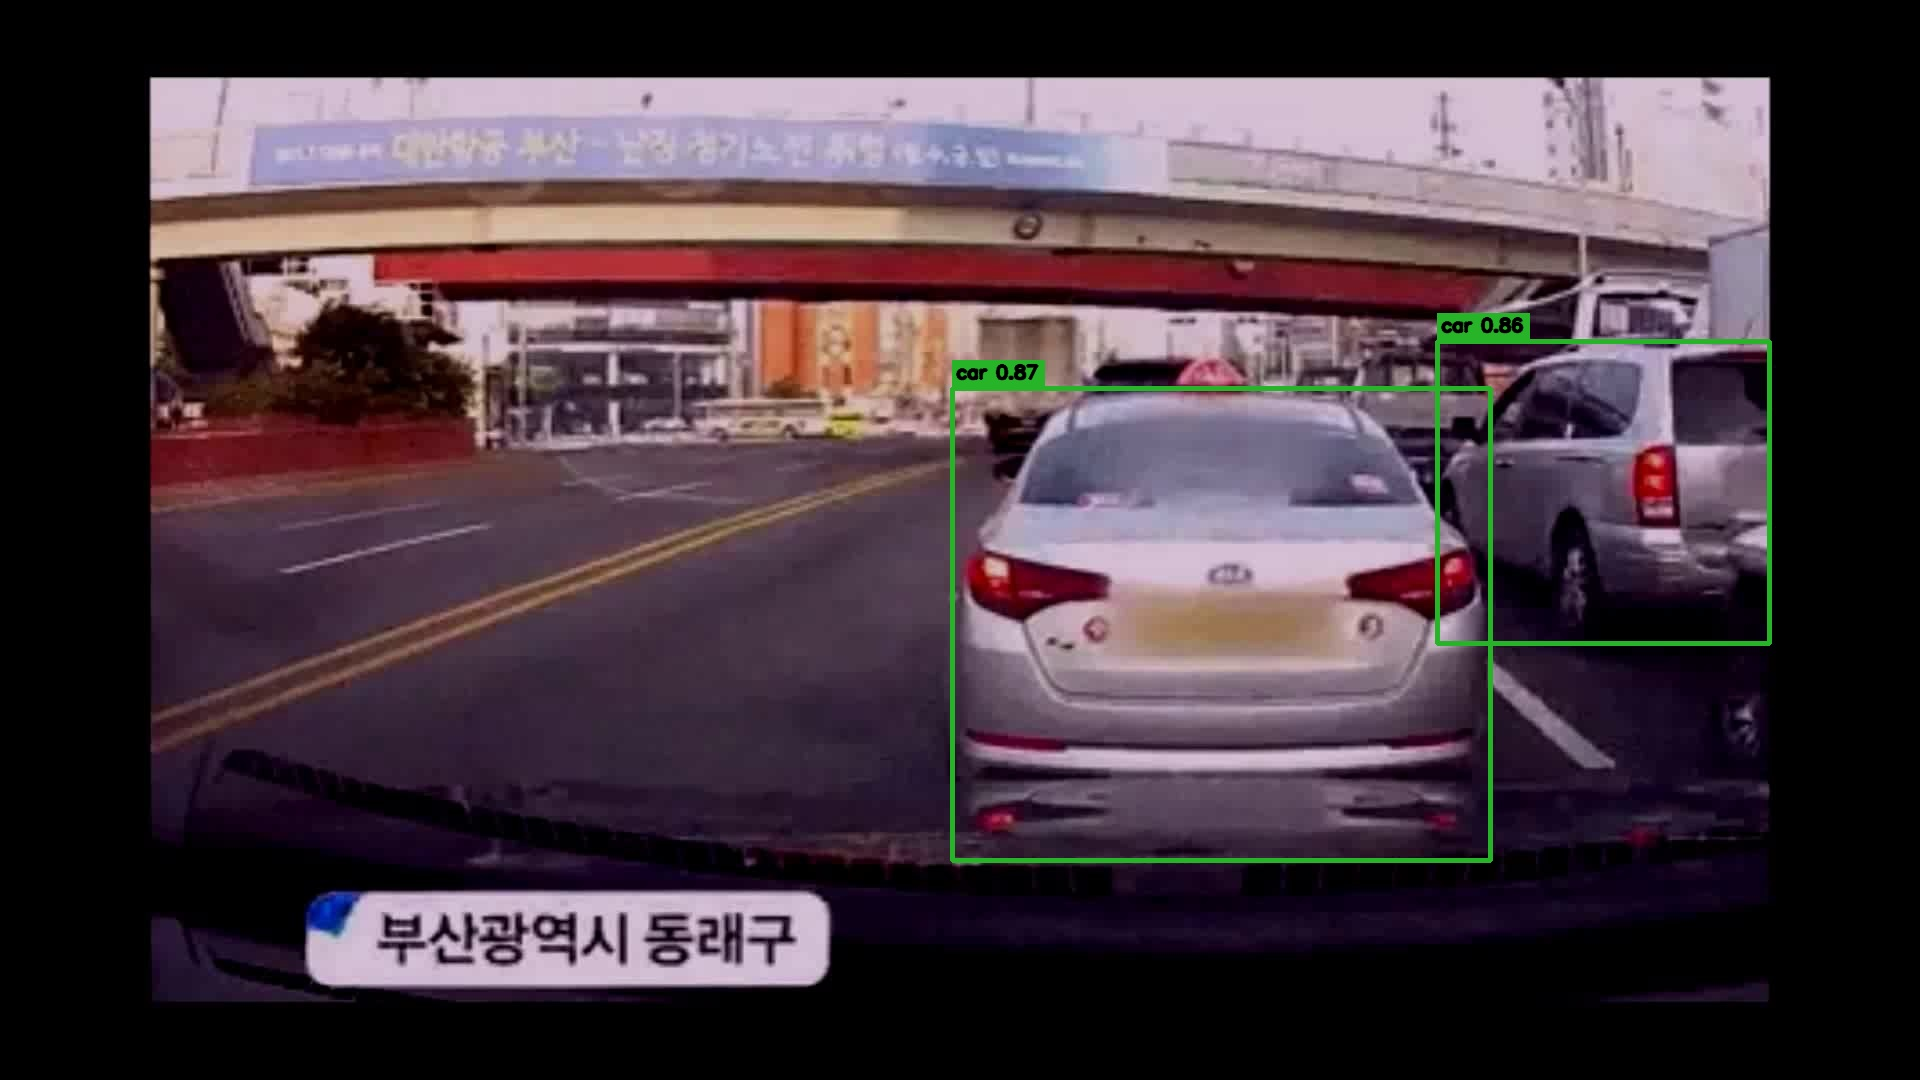

/workspace/SKN27-FINAL-3Team/storage/vision/outputs/visualizations/bb_3_190909_pedestrian_226_21450_frame_02_000037_bbox.jpg


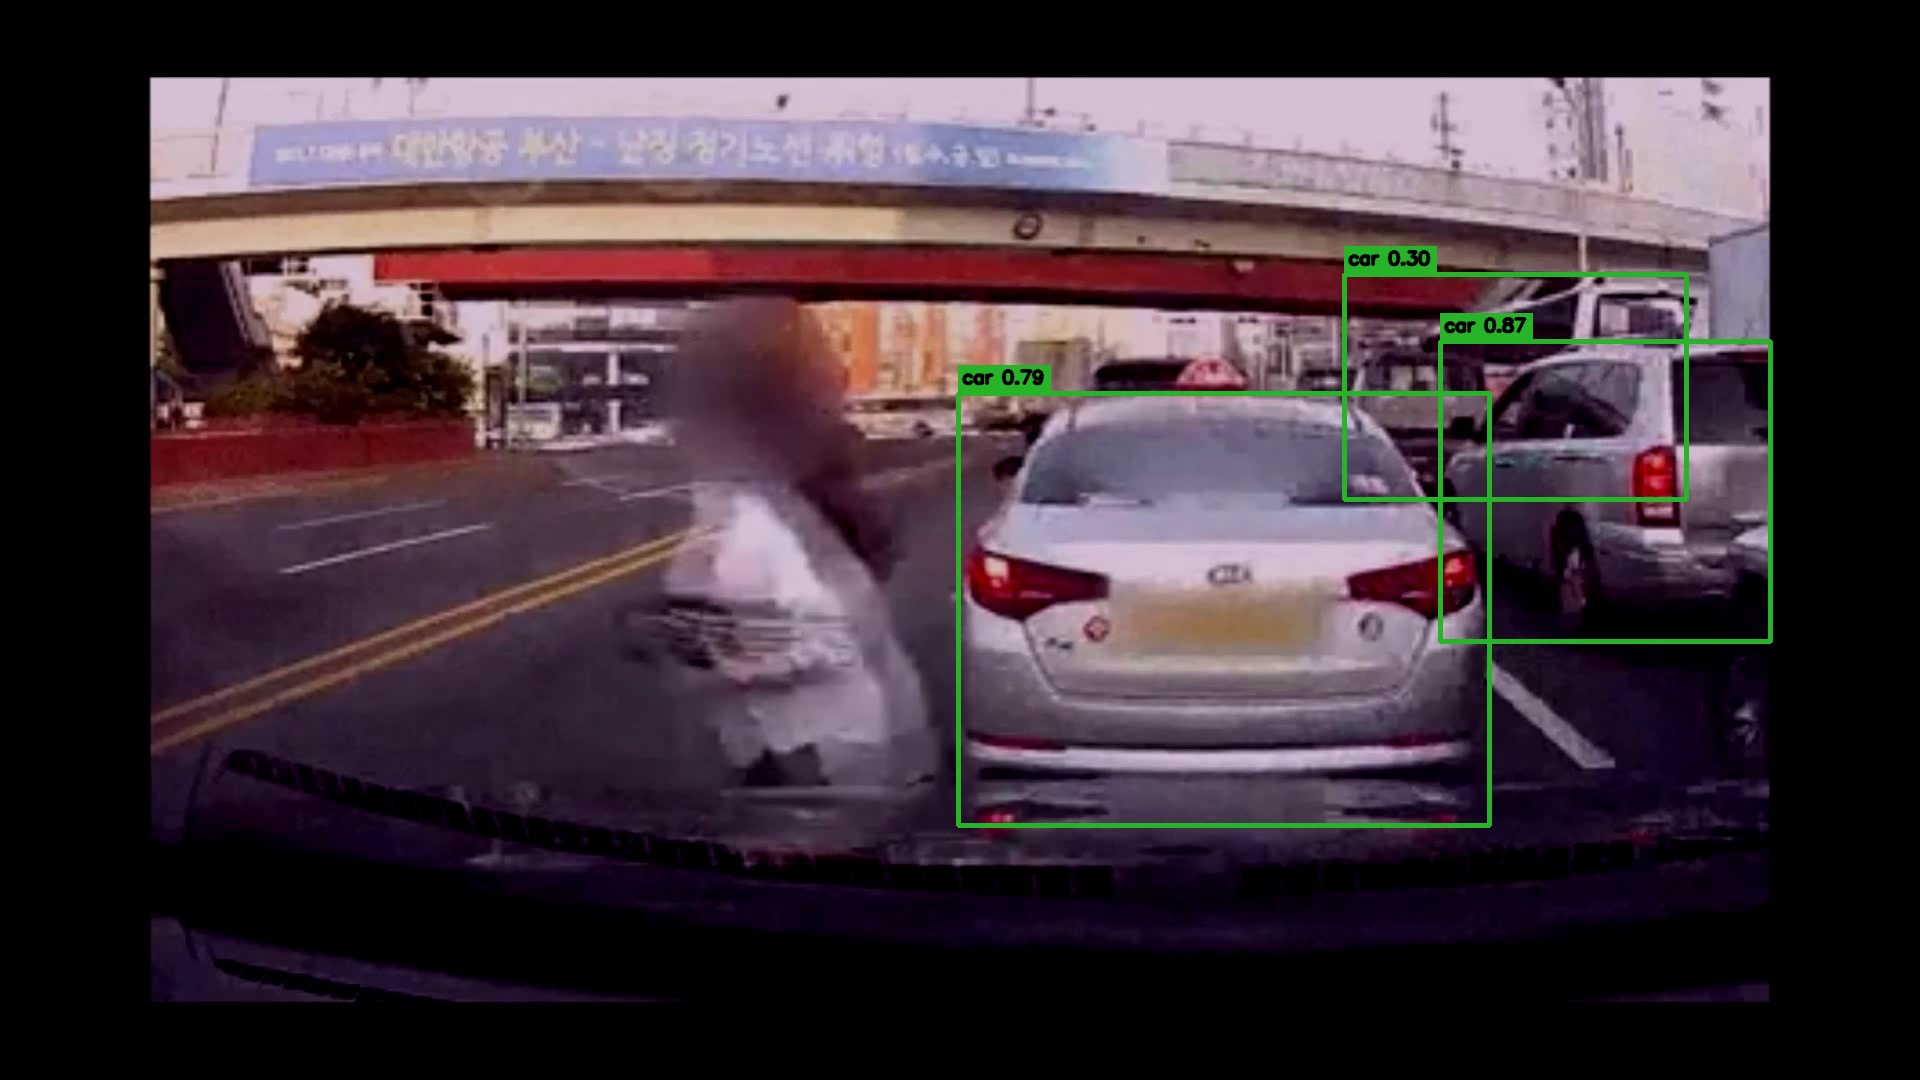

/workspace/SKN27-FINAL-3Team/storage/vision/outputs/visualizations/bb_3_190909_pedestrian_226_21450_frame_03_000074_bbox.jpg


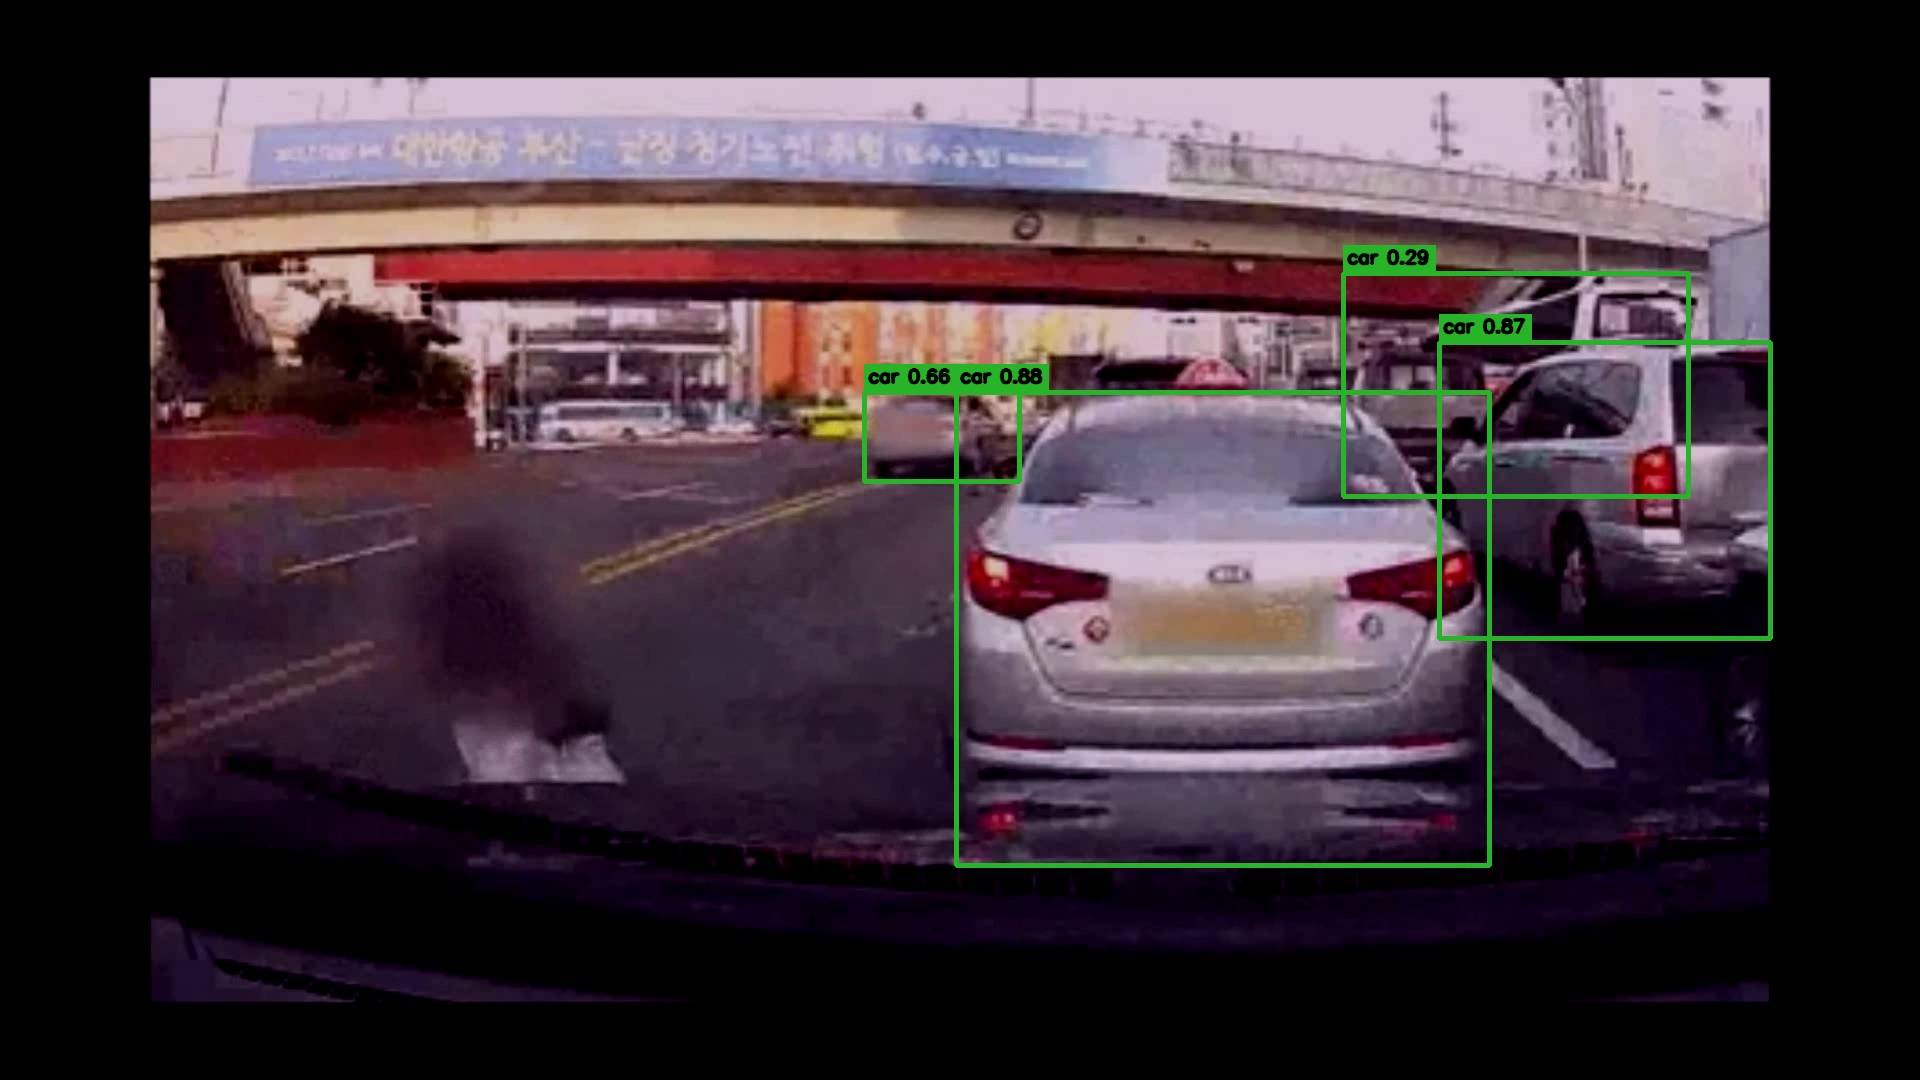

/workspace/SKN27-FINAL-3Team/storage/vision/outputs/visualizations/bb_3_190909_pedestrian_226_21450_frame_04_000112_bbox.jpg


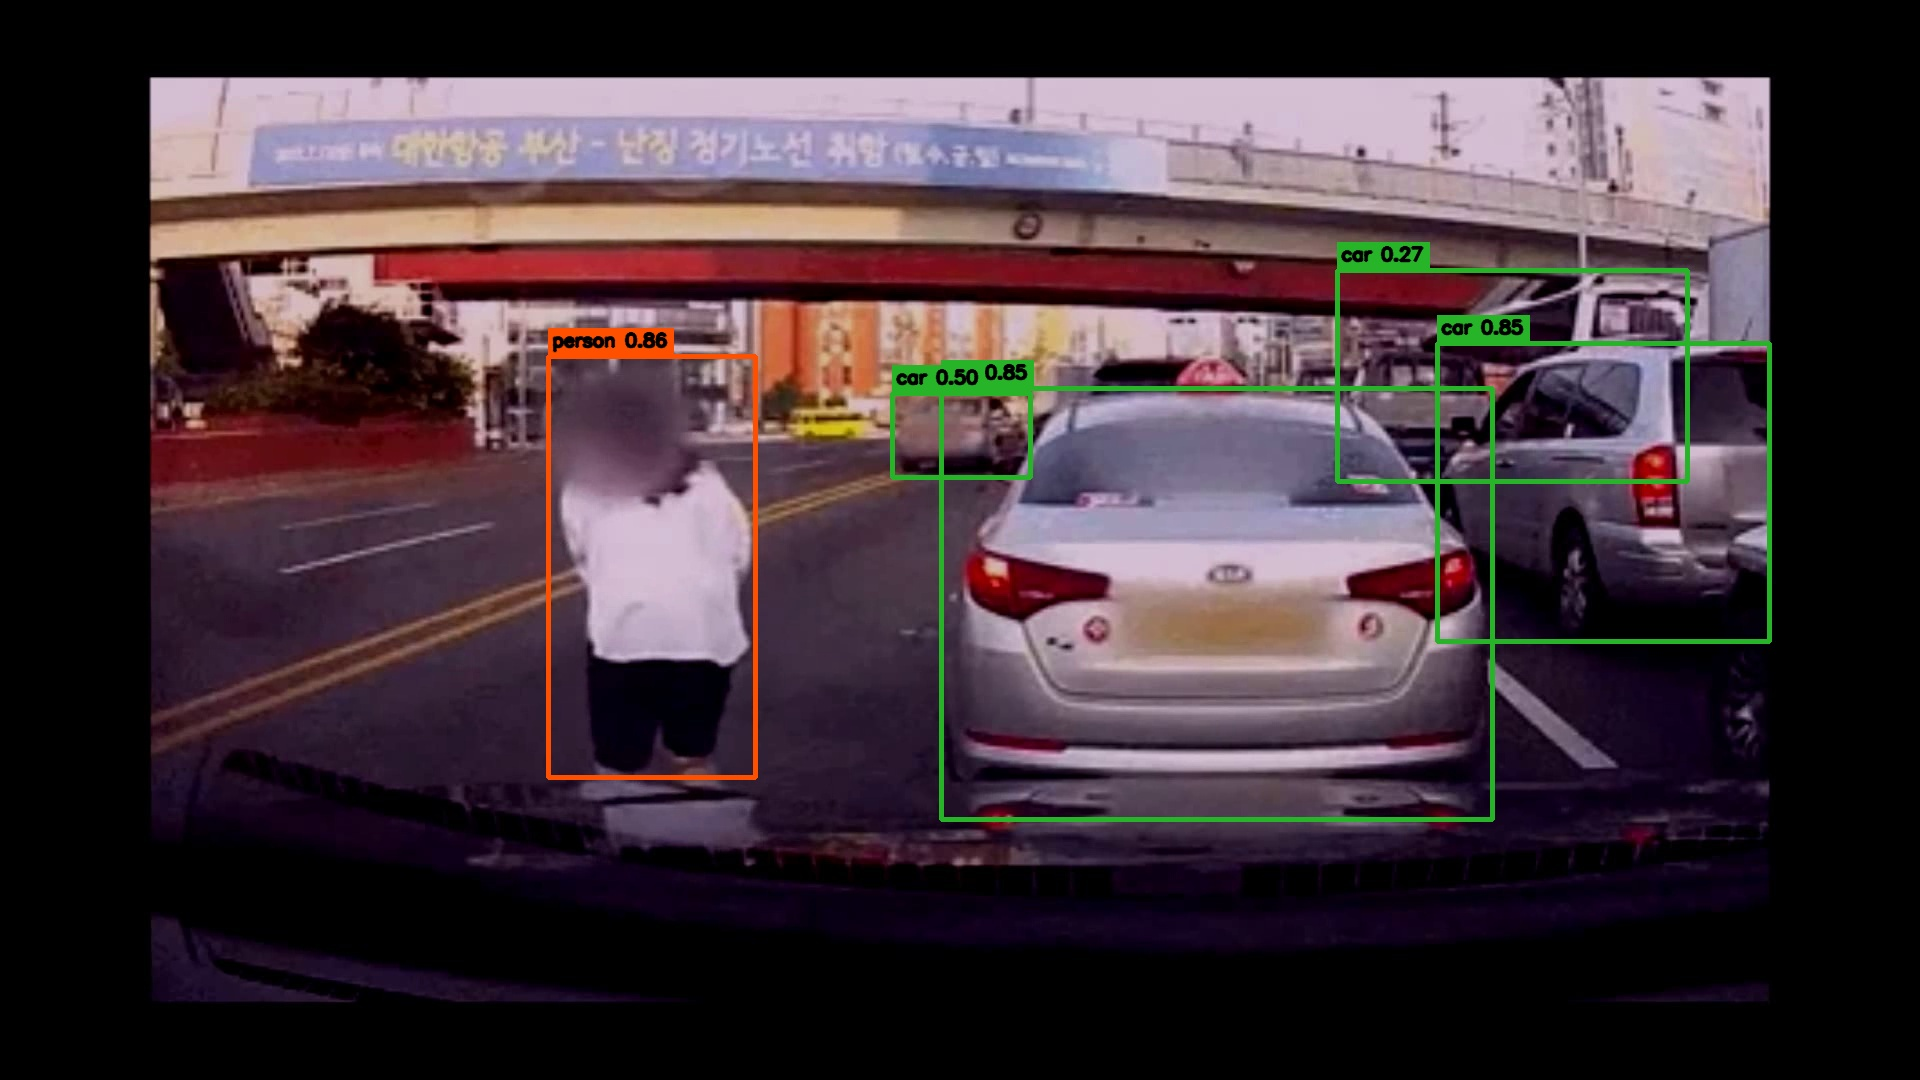

/workspace/SKN27-FINAL-3Team/storage/vision/outputs/visualizations/bb_3_190909_pedestrian_226_21450_frame_05_000149_bbox.jpg


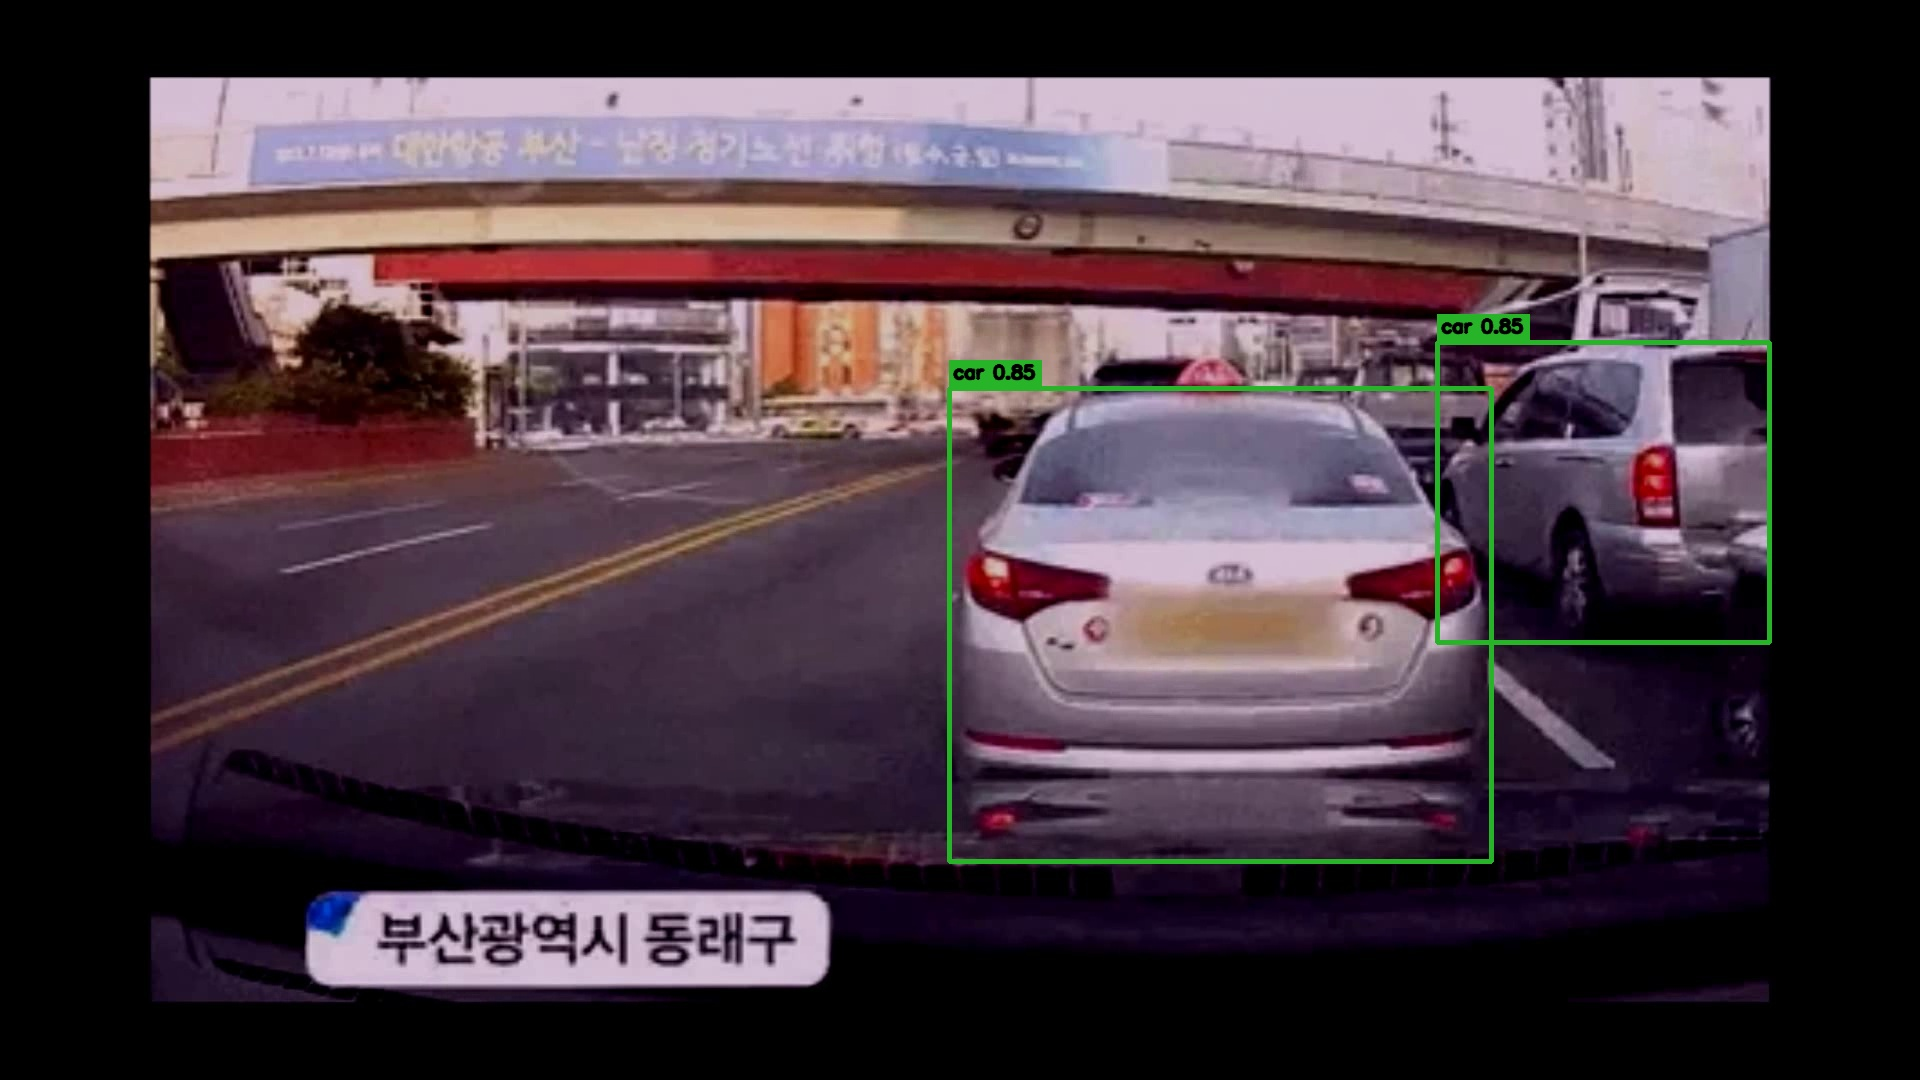

In [7]:
vis_images = sorted(VIS_DIR.glob("*_bbox.jpg"))
print("visualization_images:", len(vis_images))
for image_path in vis_images[:5]:
    print(image_path)
    display(Image(filename=str(image_path), width=640))


## 8. Review grounded summary and unavailable items

The field summary must only use observed evidence. Fault ratio, liable party, and legal responsibility stay unavailable here.


In [8]:
print("[field_summary]")
print(result.get("field_summary"))

print("\n[unavailable_items]")
for item in result.get("unavailable_items", []):
    print("-", item["item"], ":", item["reason"])

print("\n[limitations]")
for item in result.get("limitations", []):
    print("-", item["type"], ":", item["message"])


[field_summary]
2.933~9.467초 구간이 우선 확인 후보로 생성되었습니다. 탐지된 주요 객체는 car 15건, person 1건입니다. 4.933~7.467초 사이 객체 위치 또는 등장 변화가 가장 크게 관찰되었습니다. 영상만으로 사고유형, 과실비율, 가해 차량, 법적 책임은 확정하지 않습니다.

[unavailable_items]
- fault_ratio : Vision 단독 결과로 과실비율을 산정하지 않습니다.
- liable_party : 단일 카메라 영상만으로 책임 주체를 확정하지 않습니다.
- traffic_violation : 신호 상태와 법규 위반은 추가 정보 확인이 필요합니다.
- final_accident_type : 사용자 진술과 RAG 판단을 함께 확인해야 합니다.

[limitations]
- poc_baseline_limit : 현재 결과는 균등 key frame과 YOLO 객체 탐지 기반 POC입니다.
- tracking_limit : 동일 객체 추적 모델 없이 class 단위 bbox 변화로 사건 후보를 추정합니다.
- legal_limit : 과실비율, 법적 책임, 신호 위반 여부를 확정하지 않습니다.


## 9. Regenerate Agent Output when needed

Use this only after changing `ai/vision/schemas.py`. It keeps the same detection JSON and regenerates the normalized output.


In [9]:
# Run only when needed.
# import sys
# !{sys.executable} {PROJECT_ROOT / 'ai/vision/schemas.py'}


## 10. Review extracted event clips

Load clip candidate JSON and extracted mp4 clips. These clips are the local input candidates for later VideoMAE comparison POC.


In [10]:
from IPython.display import Video

CLIP_CANDIDATE_DIR = OUTPUT_DIR / "clip_candidates"
CLIP_DIR = PROJECT_ROOT / "storage/vision/processed/clips"

clip_candidate_path = latest(CLIP_CANDIDATE_DIR, "clip_candidates_*.json")
clip_candidate_data = json.loads(clip_candidate_path.read_text(encoding="utf-8"))

print("clip_candidate_path:", clip_candidate_path)
print("candidate_count:", clip_candidate_data.get("candidate_count"))
for item in clip_candidate_data.get("clip_candidates", []):
    print(json.dumps(item, ensure_ascii=False, indent=2))


clip_candidate_path: /workspace/SKN27-FINAL-3Team/storage/vision/outputs/clip_candidates/clip_candidates_bb_3_190909_pedestrian_226_21450.json
candidate_count: 1
{
  "clip_id": "clip_01",
  "source_video": "storage/vision/raw/bb_3_190909_pedestrian_226_21450.mp4",
  "clip_start_sec": 0.0,
  "clip_end_sec": 10.0,
  "clip_duration_sec": 10.0,
  "priority_score": 1.0,
  "source_refs": [],
  "basis": "short_video_full_context",
  "clip_label_status": "candidate_for_inference",
  "planned_use": "videomae_comparison_poc"
}


## 11. Play extracted clips

If the video does not render in VS Code, open the printed mp4 path directly from the file explorer.


frame_count: 150
/workspace/SKN27-FINAL-3Team/storage/vision/processed/clips/preview_frames/clip_preview_01_000000.jpg


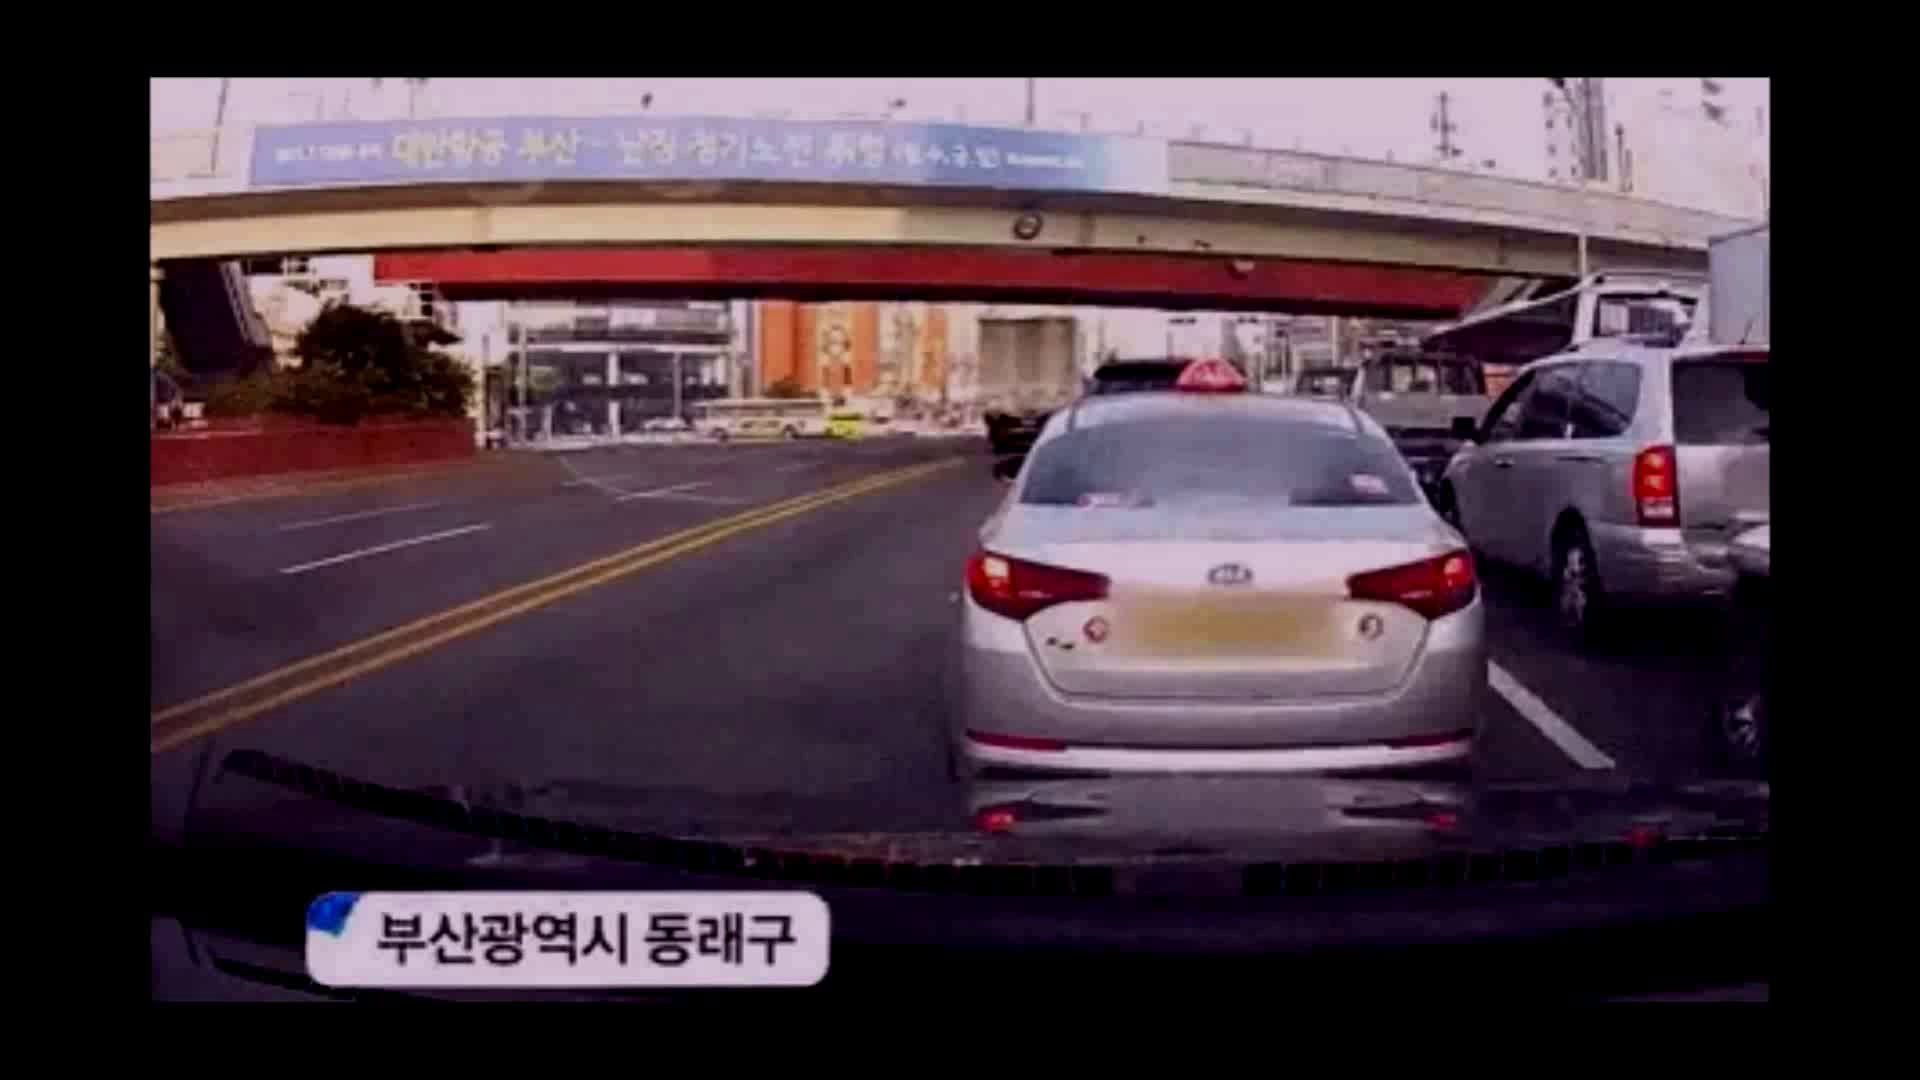

/workspace/SKN27-FINAL-3Team/storage/vision/processed/clips/preview_frames/clip_preview_02_000037.jpg


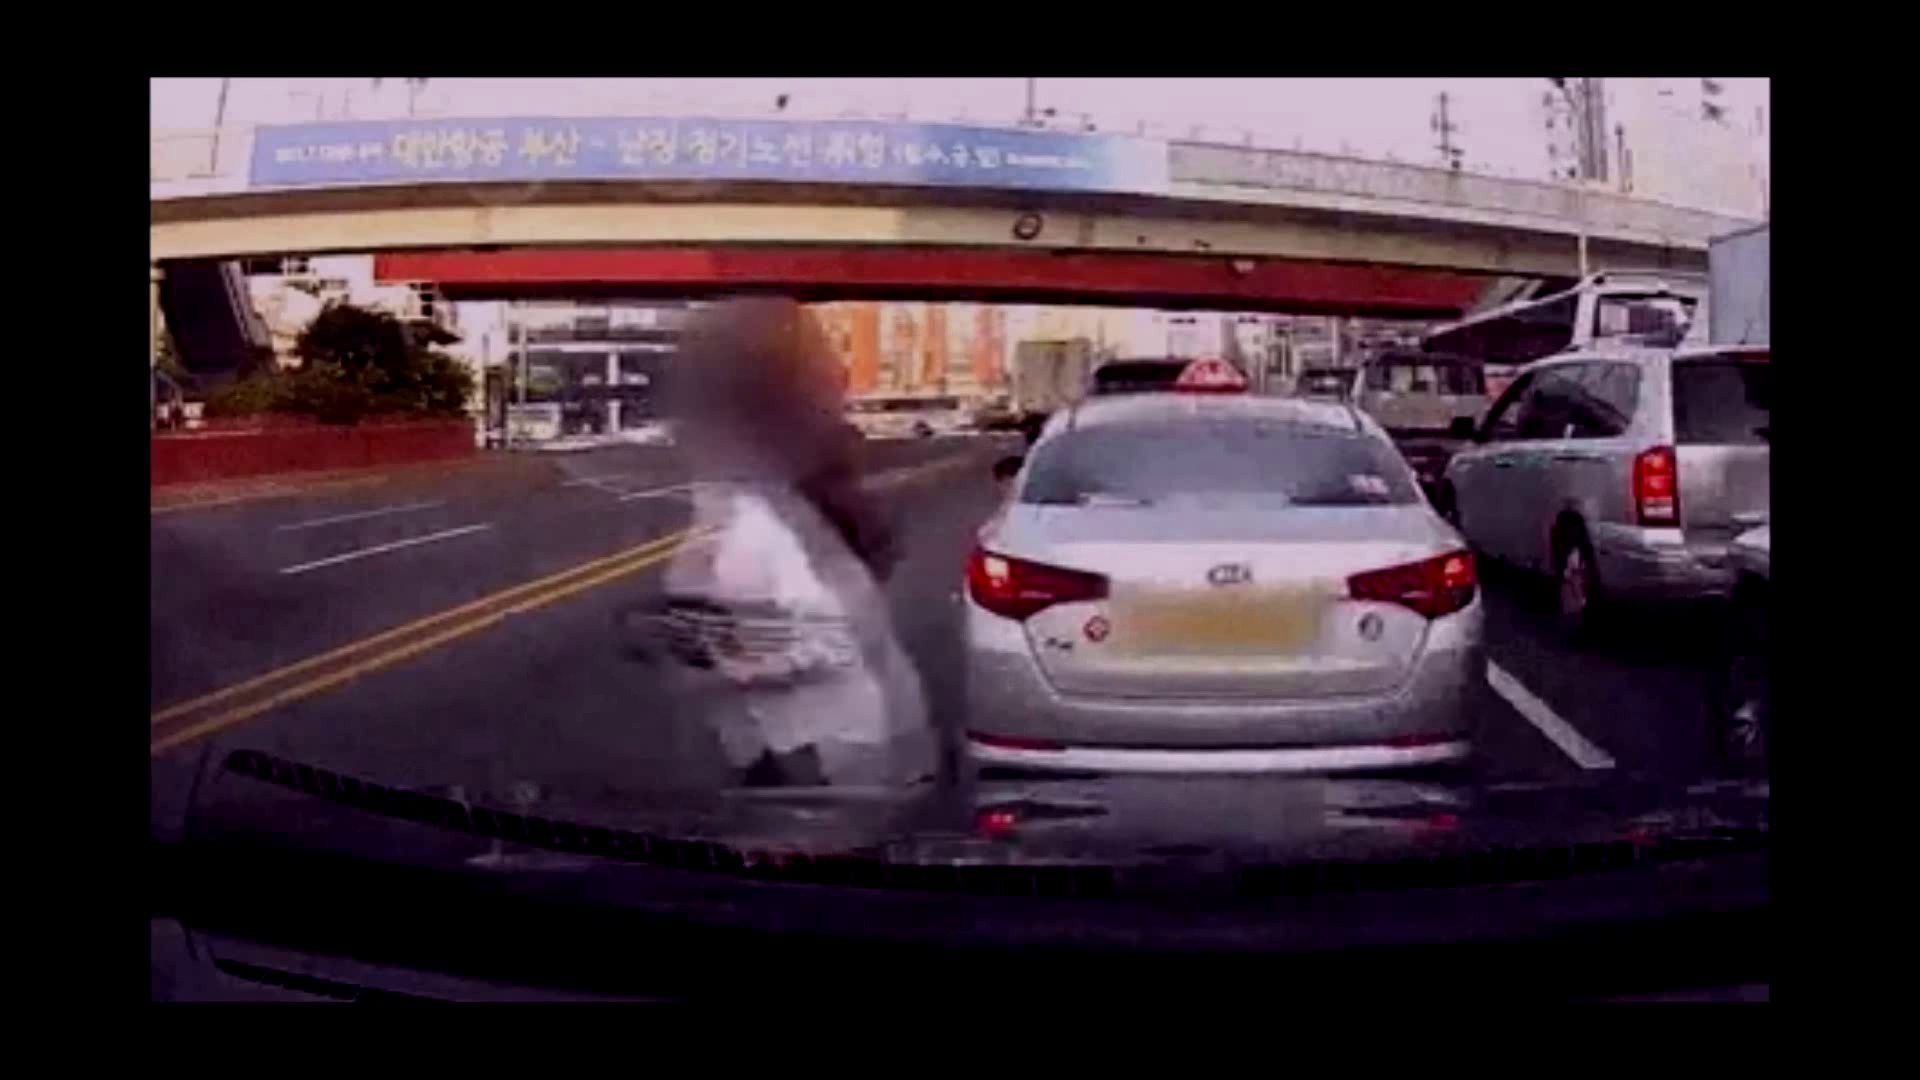

/workspace/SKN27-FINAL-3Team/storage/vision/processed/clips/preview_frames/clip_preview_03_000075.jpg


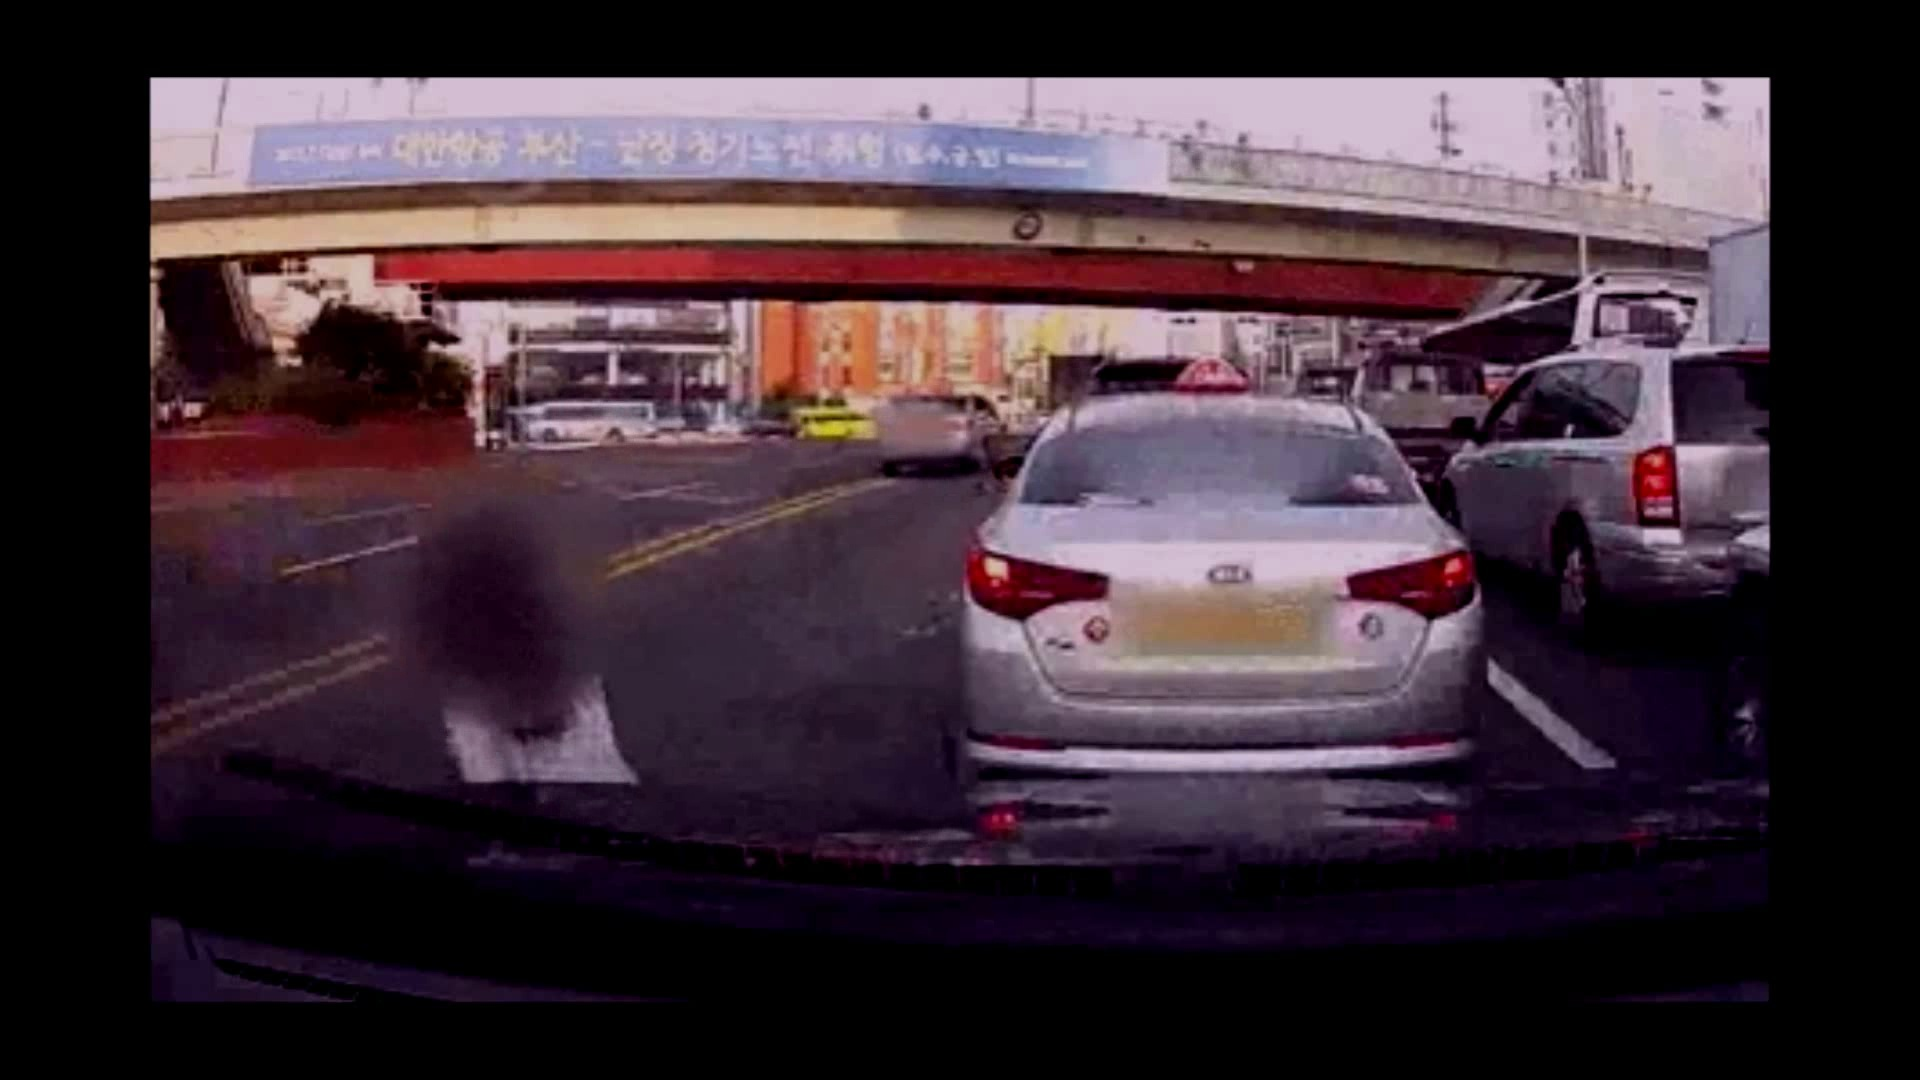

/workspace/SKN27-FINAL-3Team/storage/vision/processed/clips/preview_frames/clip_preview_04_000112.jpg


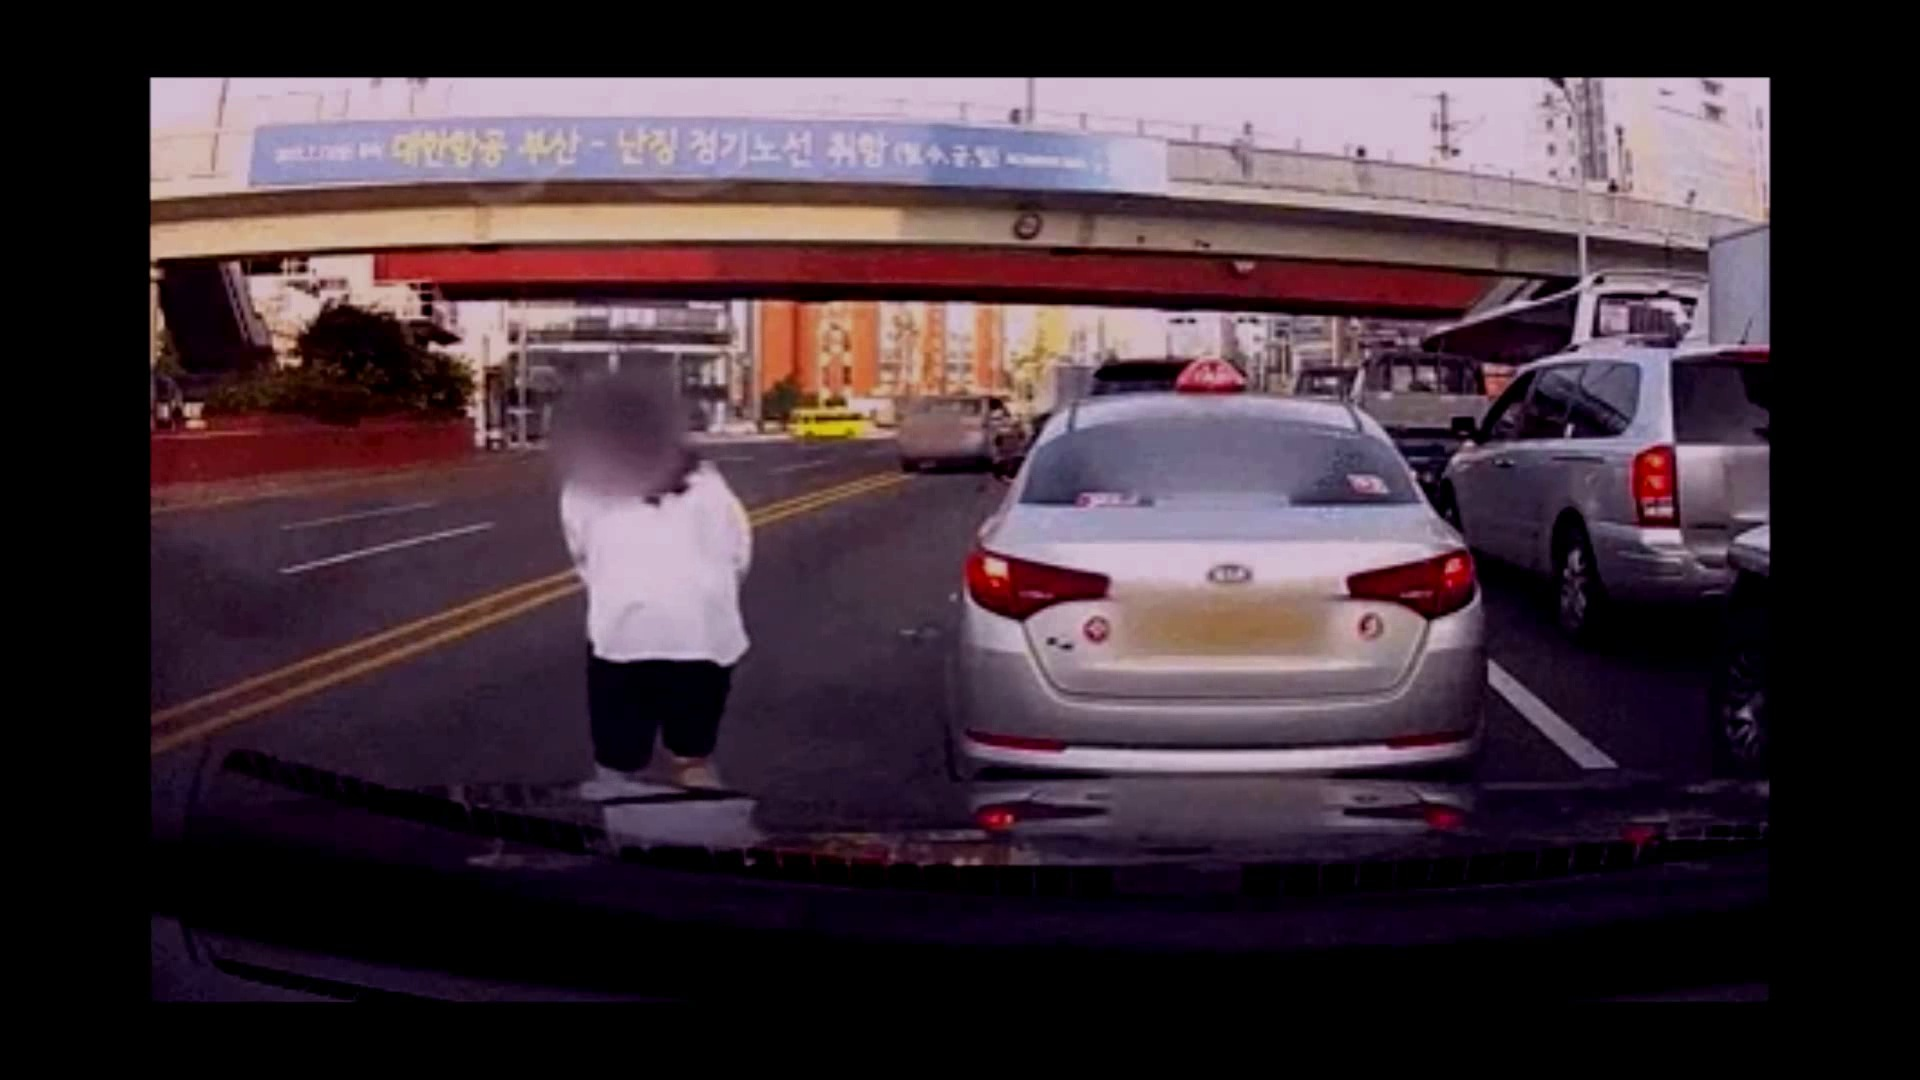

/workspace/SKN27-FINAL-3Team/storage/vision/processed/clips/preview_frames/clip_preview_05_000149.jpg


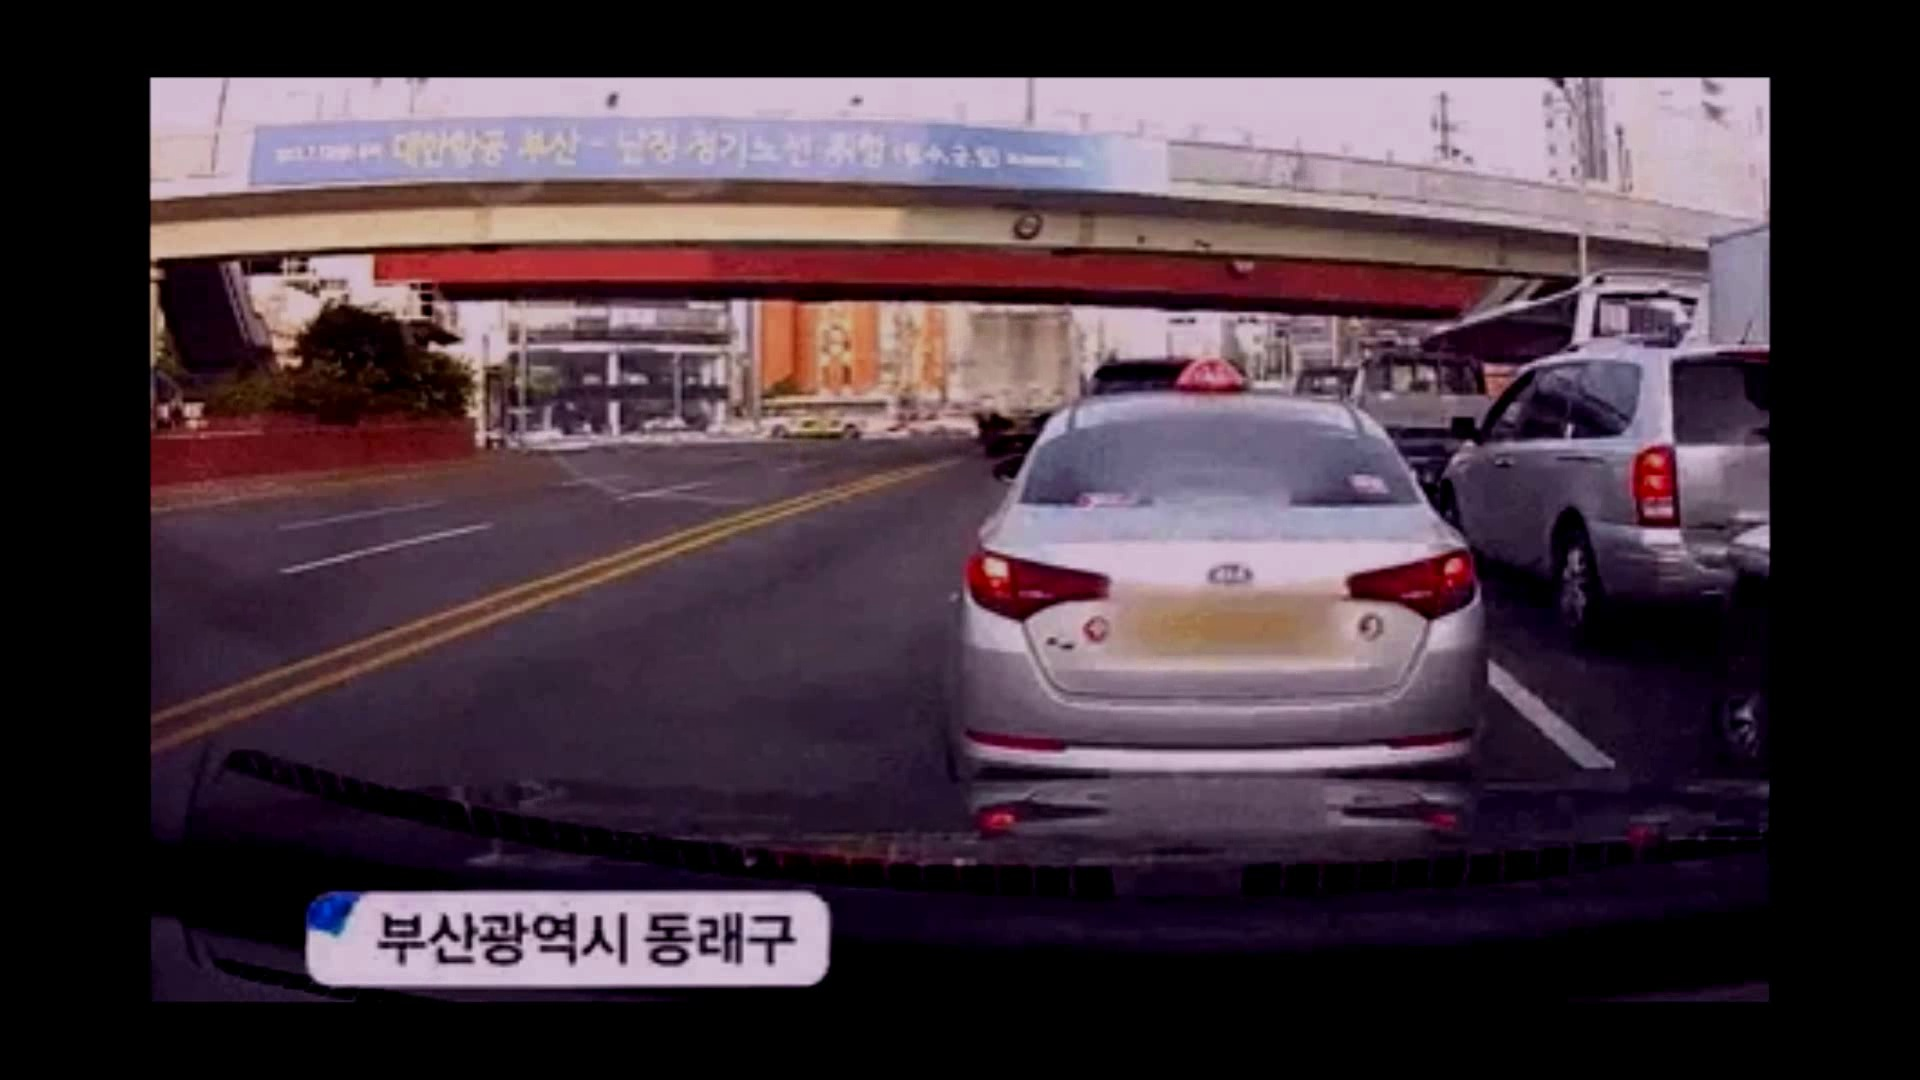

In [12]:
import cv2
from pathlib import Path
from IPython.display import Image, display

clip_path = PROJECT_ROOT / "storage/vision/processed/clips/bb_3_190909_pedestrian_226_21450_clip_01.mp4"
preview_dir = PROJECT_ROOT / "storage/vision/processed/clips/preview_frames"
preview_dir.mkdir(parents=True, exist_ok=True)

cap = cv2.VideoCapture(str(clip_path))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print("frame_count:", frame_count)

indices = [0, frame_count // 4, frame_count // 2, frame_count * 3 // 4, frame_count - 1]

for i, idx in enumerate(indices, start=1):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ok, frame = cap.read()
    if not ok:
        print("failed:", idx)
        continue

    out_path = preview_dir / f"clip_preview_{i:02d}_{idx:06d}.jpg"
    cv2.imwrite(str(out_path), frame)

    print(out_path)
    display(Image(filename=str(out_path), width=640))

cap.release()

In [16]:
from IPython.display import Video, display

h264_path = PROJECT_ROOT / "storage/vision/processed/clips/bb_3_190909_pedestrian_226_21450_clip_01_h264.mp4"

display(Video(str(h264_path), embed=True, width=480))


## 12. Review VideoMAE input frames

Check the 16 uniformly sampled frames that will be used as VideoMAE comparison POC input.


In [ ]:
VIDEOMAE_INPUT_DIR = OUTPUT_DIR / "videomae_inputs"
videomae_manifest_path = latest(VIDEOMAE_INPUT_DIR, "videomae_clip_manifest_*.json")
videomae_data = json.loads(videomae_manifest_path.read_text(encoding="utf-8"))

print("videomae_manifest_path:", videomae_manifest_path)
print("clip_count:", videomae_data.get("clip_count"))
print("target_frame_count:", videomae_data.get("target_frame_count"))

for clip in videomae_data.get("clips", []):
    print("clip_id:", clip.get("clip_id"))
    print("clip_path:", clip.get("clip_path"))
    print("metadata:", clip.get("metadata"))


## 13. Display VideoMAE sampled frames

Show all sampled frames in order. These are the frames a later VideoMAE script will consume.


In [ ]:
for clip in videomae_data.get("clips", []):
    frames = clip.get("videomae_input", {}).get("frames", [])
    print("clip_id:", clip.get("clip_id"), "frames:", len(frames))
    for frame in frames:
        frame_path = PROJECT_ROOT / frame["frame_path"]
        print(frame["frame_order"], frame["timestamp_sec"], frame_path)
        if frame_path.exists():
            display(Image(filename=str(frame_path), width=360))


## 14. Review final merged analysis

Confirm the final output that combines YOLO/bbox evidence and VideoMAE clip-level inference.


In [ ]:
# AUTO_RUN_FULL_VISION_PIPELINE
FINAL_DIR = OUTPUT_DIR / "final_analysis"
VIDEOMAE_RESULT_DIR = OUTPUT_DIR / "videomae_results"

final_analysis_path = latest(FINAL_DIR, "final_analysis_*.json")
final_data = json.loads(final_analysis_path.read_text(encoding="utf-8"))

agent = final_data["vision_agent_output"]["agent_output"]
structured = agent["structured_result"]
video = final_data["video_understanding"]

print("final_analysis_path:", final_analysis_path)
print("schema_version:", final_data.get("schema_version"))
print("status:", final_data.get("status"))
print("summary:", agent.get("summary"))
print("event_windows:", len(structured.get("event_window_candidates", [])))
print("key_frames:", len(structured.get("key_frames", [])))
print("detected_objects:", len(structured.get("detected_objects", [])))

for clip in video.get("clips", []):
    top = clip.get("top_prediction") or {}
    print("videomae:", clip.get("clip_id"), top.get("label"), top.get("score"))

print("\nlimitations")
for item in final_data.get("limitations", []):
    print("-", item)
